### 03 · XGBoost RUL — TWIN-RBI Mongstad

Este modelo se usa para predecir la Vida Útil Residual (`RUL_years`) de los equipos de la planta Mongstad usando XGBoost Regressor con optimización bayesiana de hiperparámetros.


El framework OPTUNA para la optimizacion de los Hiperparamietros es mucho mas eficiente que otros modelos de optimizacion como GridSearch ya que con CV-5 y 9 hiperparametros con 280 observaciones el tiempo de computo es mucho 

In [9]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [10]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
from pathlib import Path

# ML
import xgboost as xgb
import optuna
import shap
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)
from sklearn.inspection import permutation_importance

# Rutas
ROOT        = Path('..')
DATA_PATH   = ROOT / 'data' / 'processed' / 'features_ml_final.csv'
MODELS_DIR  = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
SEED = 42



In [11]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}  →  {df.shape[0]} obs × {df.shape[1]} features')
print(f'\nColumnas ({len(df.columns)}):')
print(df.columns.tolist())
print(f'\nTarget  → RUL_years: min={df["RUL_years"].min():.2f}  '
      f'max={df["RUL_years"].max():.2f}  '
      f'mean={df["RUL_years"].mean():.2f}  '
      f'std={df["RUL_years"].std():.2f}')
print(f'\nNulos por columna:\n{df.isnull().sum()[df.isnull().sum()>0]}')
df.head(3)

Shape: (228, 53)  →  228 obs × 53 features

Columnas (53):
['window', 'line_id', 'year', 'quarter', 'P_mean', 'P_std', 'dP_mean', 'T_process_mean', 'T_wall_mean', 'T_amb_mean', 'T_wall_std', 'h2s_mean', 'h2s_max', 'h2s_std', 'h2s_sensor_diff', 'vib_mean', 'vib_max', 'vib_std', 'arab_mean', 'arab_std', 'vapor_frac_mean', 'dew_point_mean', 'delta_T_dew_mean', 'delta_T_dew_min', 'pct_below_dew', 'cr_mean', 'cr_std', 'cr_max', 'cr_trend', 't_actual', 't_estimated', 't_ratio', 't_margin', 'insp_count', 'days_since_insp', 'last_result_alert', 'last_result_mon', 'h2s_design', 'sulfur_pct', 'consequence_area', 'financial_impact', 'insulated', 'cui_active', 'ssc_active', 'hic_active', 'sulfidation', 'fac_active', 'HSI', 'PTR', 'SAF', 'RUL_years', 'pof_category', 'RUL_years.1']

Target  → RUL_years: min=0.02  max=64.25  mean=13.76  std=17.67

Nulos por columna:
Series([], dtype: int64)


,window,line_id,year,quarter,P_mean,P_std,dP_mean,T_process_mean,T_wall_mean,T_amb_mean,...,ssc_active,hic_active,sulfidation,fac_active,HSI,PTR,SAF,RUL_years,pof_category,RUL_years.1
0,2018-Q1,E-101,2018,1,11.539,1.934,0.225,48.13,44.09,15.60,...,1,1,1,0,0.5340,0.1402,2.7145,11.31,3,11.31
1,2018-Q2,E-101,2018,2,11.883,1.759,0.269,47.62,41.78,15.96,...,1,1,1,0,0.7530,0.1429,2.6547,11.06,3,11.06
2,2018-Q3,E-101,2018,3,11.995,1.700,0.212,42.68,34.51,0.94,...,1,1,1,0,0.6611,0.1293,2.5942,10.81,3,10.81


Análisis exploratorio del target RUL_years

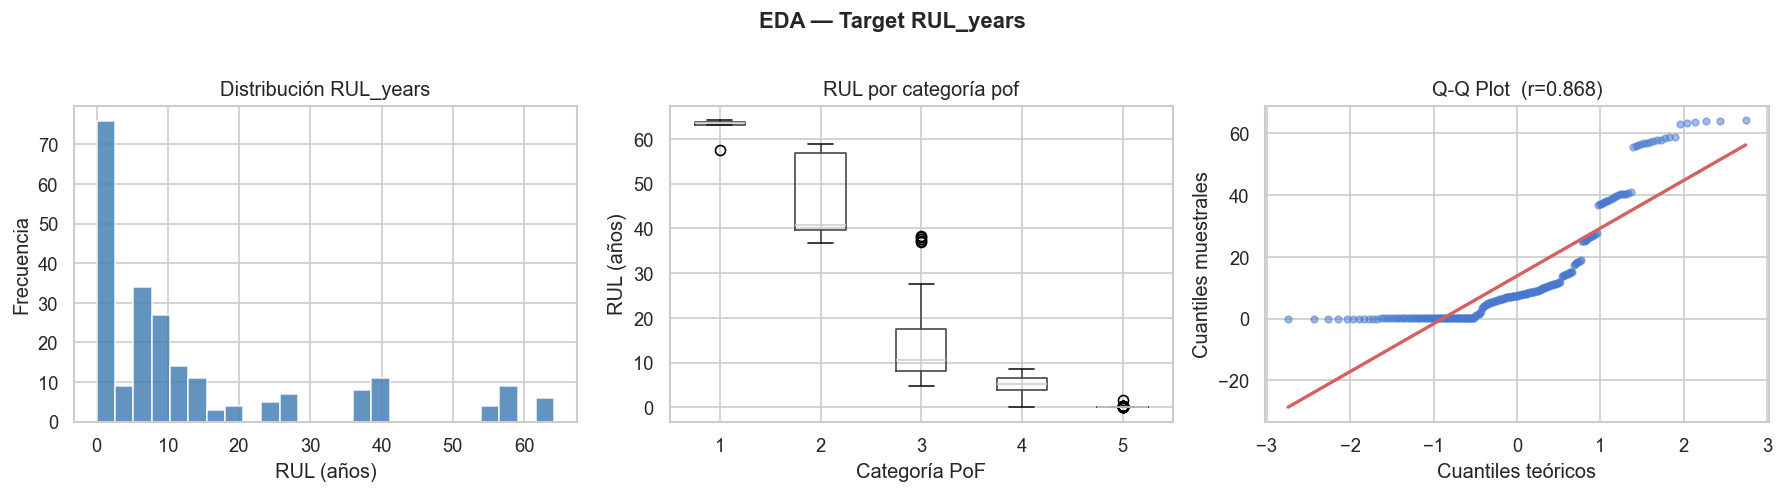

fig_rul_eda.png guardada


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución
axes[0].hist(df['RUL_years'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución RUL_years')
axes[0].set_xlabel('RUL (años)')
axes[0].set_ylabel('Frecuencia')

# Boxplot por categoría PoF (si existe)
if 'pof_category' in df.columns:
    df.boxplot(column='RUL_years', by='pof_category', ax=axes[1])
    axes[1].set_title('RUL por categoría pof')
    axes[1].set_xlabel('Categoría PoF')
    axes[1].set_ylabel('RUL (años)')
    plt.sca(axes[1])
    plt.title('RUL por categoría pof')
else:
    axes[1].text(0.5, 0.5, 'pof_category\nno disponible',
                 ha='center', va='center', transform=axes[1].transAxes)

# QQ-plot aproximado (percentiles)
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(df['RUL_years'], dist='norm')
axes[2].plot(osm, osr, 'o', alpha=0.5, markersize=4)
axes[2].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
axes[2].set_title(f'Q-Q Plot  (r={r:.3f})')
axes[2].set_xlabel('Cuantiles teóricos')
axes[2].set_ylabel('Cuantiles muestrales')

plt.suptitle('EDA — Target RUL_years', y=1.02, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_rul_eda.png', bbox_inches='tight')
plt.show()
print('fig_rul_eda.png guardada')

Preprocesamiento

In [13]:
TARGET = 'RUL_years'


EXCLUDE_COLS = [TARGET, 'equipment_id', 'tag', 'timestamp', 'PoF_label', 'PoF_category']
feat_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feat_cols].copy()
y = df[TARGET].copy()

# Encodificar categoricas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Columnas categóricas a encodificar: {cat_cols}')
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Imputar nulos con mediana
X = X.fillna(X.median(numeric_only=True))

print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Features: {feat_cols[:10]} ... ({len(feat_cols)} total)')

# Split estratificado por bins de RUL
y_bins = pd.cut(y, bins=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y_bins
)
print(f'\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Columnas categóricas a encodificar: ['window', 'line_id']

X shape : (228, 52)
y shape : (228,)
Features: ['window', 'line_id', 'year', 'quarter', 'P_mean', 'P_std', 'dP_mean', 'T_process_mean', 'T_wall_mean', 'T_amb_mean'] ... (52 total)

Train: 182  |  Test: 46


Baseline XGBoost

In [14]:
xgb_baseline = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_base = xgb_baseline.predict(X_test)

mae_b  = mean_absolute_error(y_test, y_pred_base)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_b   = r2_score(y_test, y_pred_base)
mape_b = mean_absolute_percentage_error(y_test, y_pred_base) * 100

print('=== BASELINE XGBoost ===')
print(f'  MAE  : {mae_b:.4f} años')
print(f'  RMSE : {rmse_b:.4f} años')
print(f'  R²   : {r2_b:.4f}')
print(f'  MAPE : {mape_b:.2f}%')

# CV-5 en train
cv_scores = cross_val_score(
    xgb_baseline, X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='r2', n_jobs=-1
)
print(f'\n  CV-5 R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== BASELINE XGBoost ===
  MAE  : 0.2194 años
  RMSE : 0.3770 años
  R²   : 0.9996
  MAPE : 6.48%

  CV-5 R²: 0.9986 ± 0.0016


Optimización Bayesiana con Optuna

In [15]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 800),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state'      : SEED,
        'n_jobs'            : -1,
        'verbosity'         : 0
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    return scores.mean()   # maximizar (negativo → minimizar MAE)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f'\n✅ Optuna completado — {len(study.trials)} trials')
print(f'   Mejor MAE (CV): {-study.best_value:.4f} años')
print(f'   Mejores params: {study.best_params}')

  0%|          | 0/60 [00:00<?, ?it/s]


✅ Optuna completado — 60 trials
   Mejor MAE (CV): 0.2161 años
   Mejores params: {'n_estimators': 783, 'max_depth': 3, 'learning_rate': 0.045854368517185294, 'subsample': 0.8831604636540767, 'colsample_bytree': 0.9438763409869122, 'min_child_weight': 3, 'gamma': 0.19239019311672062, 'reg_alpha': 2.383629043142624e-05, 'reg_lambda': 0.000511987150782416}


In [16]:
# Entrenar modelo final con mejores hiperparámetros
best_params = study.best_params.copy()
best_params.update({'random_state': SEED, 'n_jobs': -1, 'verbosity': 0})

xgb_final = xgb.XGBRegressor(**best_params)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = xgb_final.predict(X_test)
y_pred_train = xgb_final.predict(X_train)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print('=== MODELO FINAL (Optimizado) ===')
print(f'  MAE  : {mae:.4f} años   (baseline: {mae_b:.4f})')
print(f'  RMSE : {rmse:.4f} años   (baseline: {rmse_b:.4f})')
print(f'  R²   : {r2:.4f}         (baseline: {r2_b:.4f})')
print(f'  MAPE : {mape:.2f}%        (baseline: {mape_b:.2f}%)')
print(f'  Mejora R²: +{(r2-r2_b)*100:.2f} pp')

=== MODELO FINAL (Optimizado) ===
  MAE  : 0.2249 años   (baseline: 0.2194)
  RMSE : 0.3834 años   (baseline: 0.3770)
  R²   : 0.9996         (baseline: 0.9996)
  MAPE : 41.30%        (baseline: 6.48%)
  Mejora R²: +-0.00 pp


Evaluación visual & curvas de aprendizaje

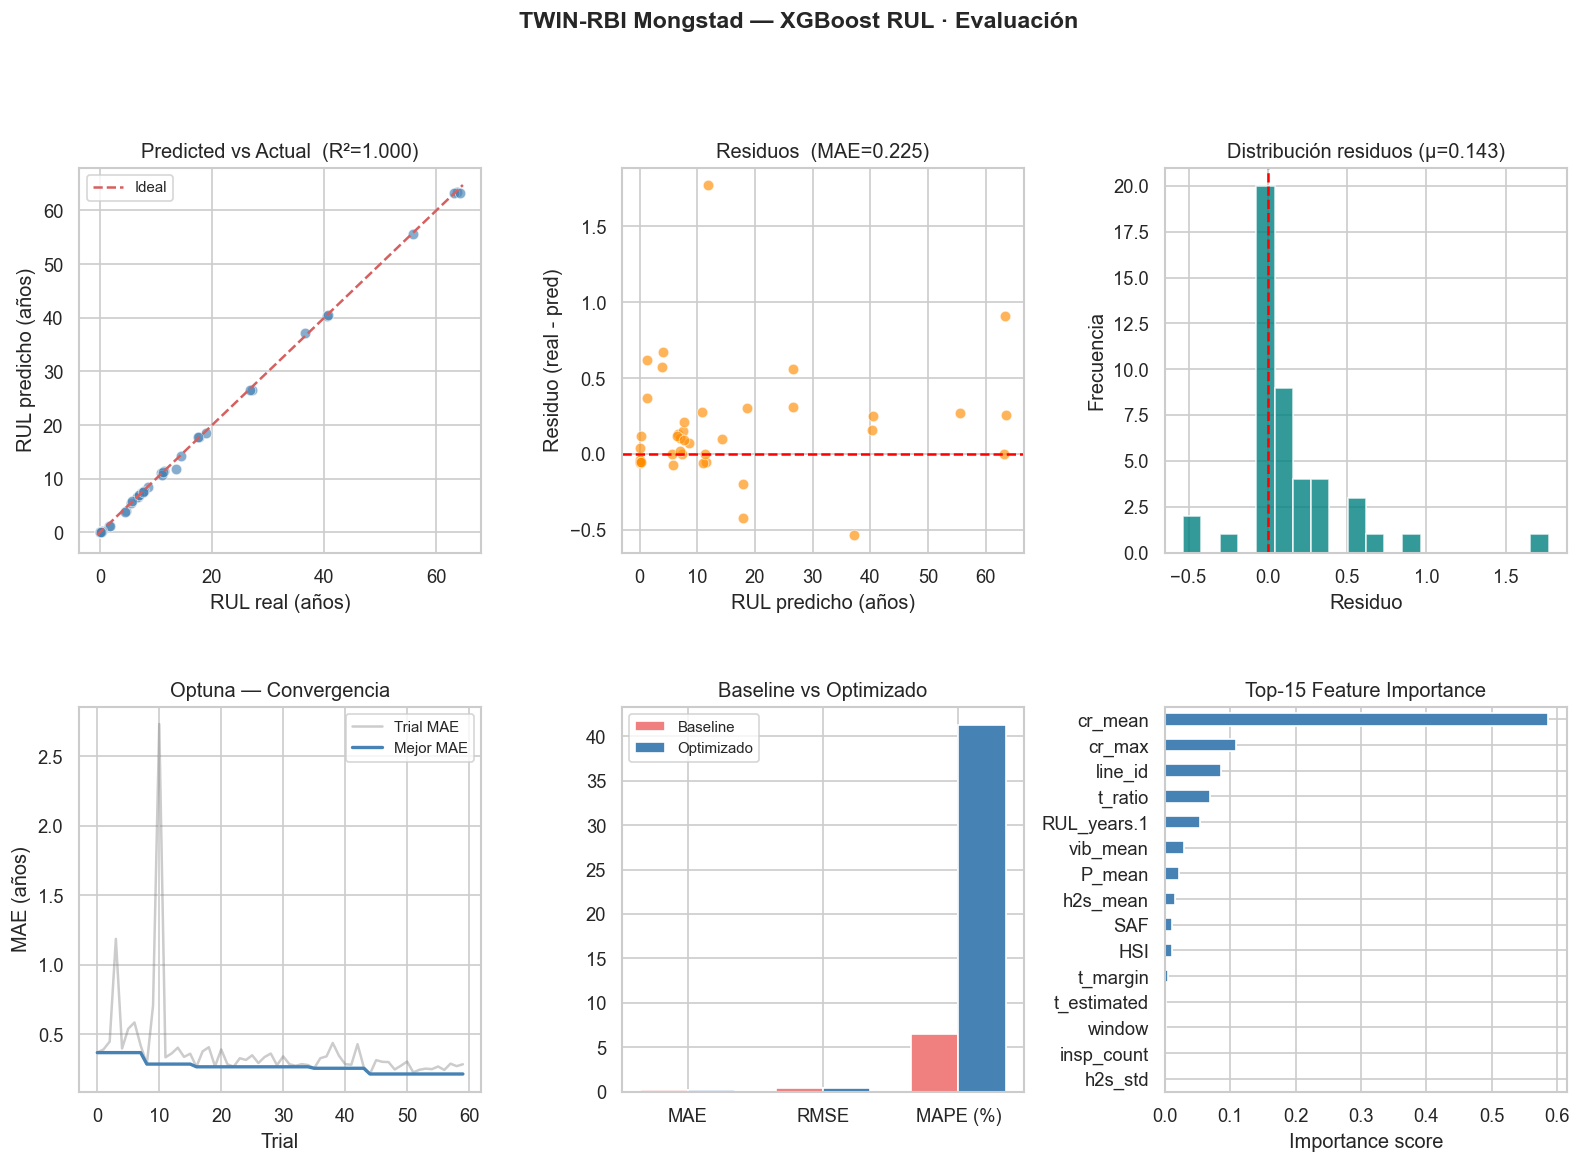

fig_xgboost_rul_eval.png guardada


In [24]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Predicted vs Actual
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.65, s=40, c='steelblue', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min())-0.5, max(y_test.max(), y_pred.max())+0.5]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Ideal')
ax1.set_xlabel('RUL real (años)')
ax1.set_ylabel('RUL predicho (años)')
ax1.set_title(f'Predicted vs Actual  (R²={r2:.3f})')
ax1.legend(fontsize=9)

# 2. Residuos
ax2 = fig.add_subplot(gs[0, 1])
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.65, s=40, c='darkorange', edgecolors='white', lw=0.5)
ax2.axhline(0, color='red', lw=1.5, ls='--')
ax2.set_xlabel('RUL predicho (años)')
ax2.set_ylabel('Residuo (real - pred)')
ax2.set_title(f'Residuos  (MAE={mae:.3f})')

# 3. Distribución de residuos
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(residuals, bins=20, color='teal', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', lw=1.5, ls='--')
ax3.set_xlabel('Residuo')
ax3.set_ylabel('Frecuencia')
ax3.set_title(f'Distribución residuos (μ={residuals.mean():.3f})')

# 4. Optuna optimization history
ax4 = fig.add_subplot(gs[1, 0])
trial_values = [-t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()
ax4.plot(trial_values, alpha=0.4, color='gray', label='Trial MAE')
ax4.plot(best_so_far.values, color='steelblue', lw=2, label='Mejor MAE')
ax4.set_xlabel('Trial')
ax4.set_ylabel('MAE (años)')
ax4.set_title('Optuna — Convergencia')
ax4.legend(fontsize=9)

# 5. Comparación Baseline vs Optimizado
ax5 = fig.add_subplot(gs[1, 1])
metrics_labels = ['MAE', 'RMSE', 'MAPE (%)']
baseline_vals  = [mae_b, rmse_b, mape_b]
final_vals     = [mae, rmse, mape]
x = np.arange(len(metrics_labels))
w = 0.35
ax5.bar(x - w/2, baseline_vals, w, label='Baseline', color='lightcoral', edgecolor='white')
ax5.bar(x + w/2, final_vals,    w, label='Optimizado', color='steelblue', edgecolor='white')
ax5.set_xticks(x)
ax5.set_xticklabels(metrics_labels)
ax5.set_title('Baseline vs Optimizado')
ax5.legend(fontsize=9)

# 6. Top-15 feature importance
ax6 = fig.add_subplot(gs[1, 2])
fi = pd.Series(xgb_final.feature_importances_, index=X_train.columns)
fi.nlargest(15).sort_values().plot(kind='barh', ax=ax6, color='steelblue', edgecolor='white')
ax6.set_title('Top-15 Feature Importance')
ax6.set_xlabel('Importance score')

fig.suptitle('TWIN-RBI Mongstad — XGBoost RUL · Evaluación', fontsize=14, fontweight='bold', y=1.01)
fig.savefig(FIGURES_DIR / 'fig_xgboost_rul_eval.png', bbox_inches='tight')
plt.show()
print('fig_xgboost_rul_eval.png guardada')

SHAP Explainability

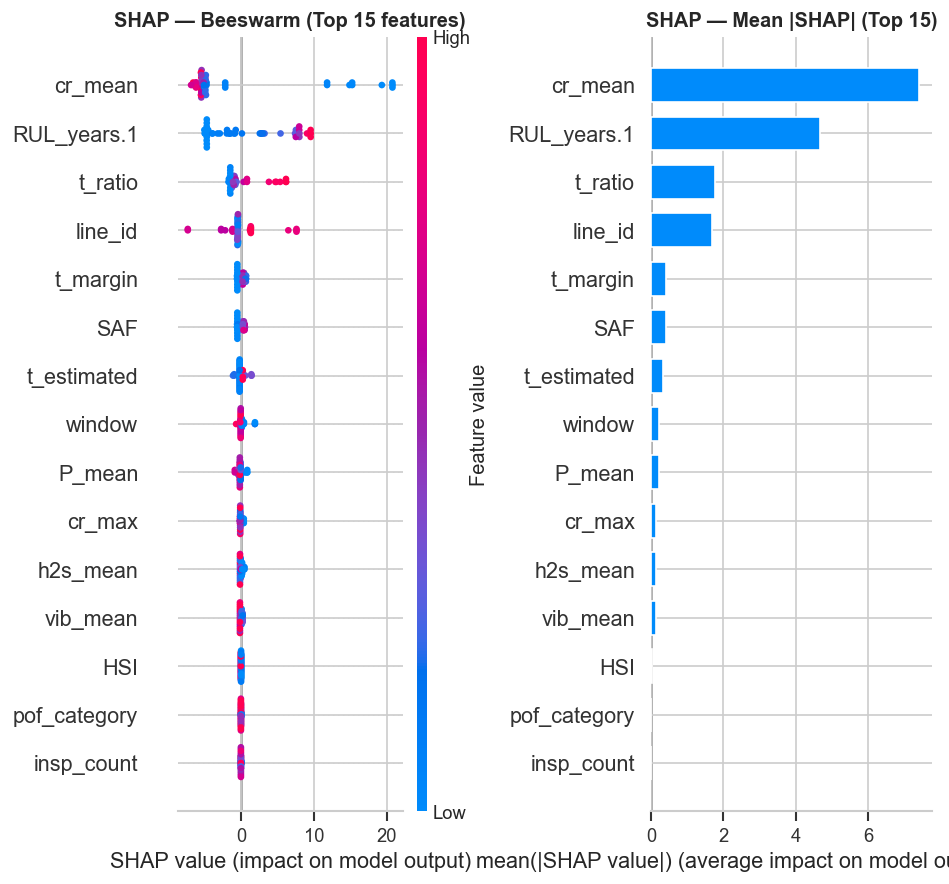

fig_shap_rul.png guardada


In [23]:
# SHAP TreeExplainer
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

fig_shap, axes_shap = plt.subplots(1, 2, figsize=(16, 6))

# Beeswarm (summary)
plt.sca(axes_shap[0])
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
axes_shap[0].set_title('SHAP — Beeswarm (Top 15 features)', fontweight='bold')

# Bar chart
plt.sca(axes_shap[1])
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
axes_shap[1].set_title('SHAP — Mean |SHAP| (Top 15)', fontweight='bold')

plt.tight_layout()
fig_shap.savefig(FIGURES_DIR / 'fig_shap_rul.png', bbox_inches='tight')
plt.show()
print('fig_shap_rul.png guardada')

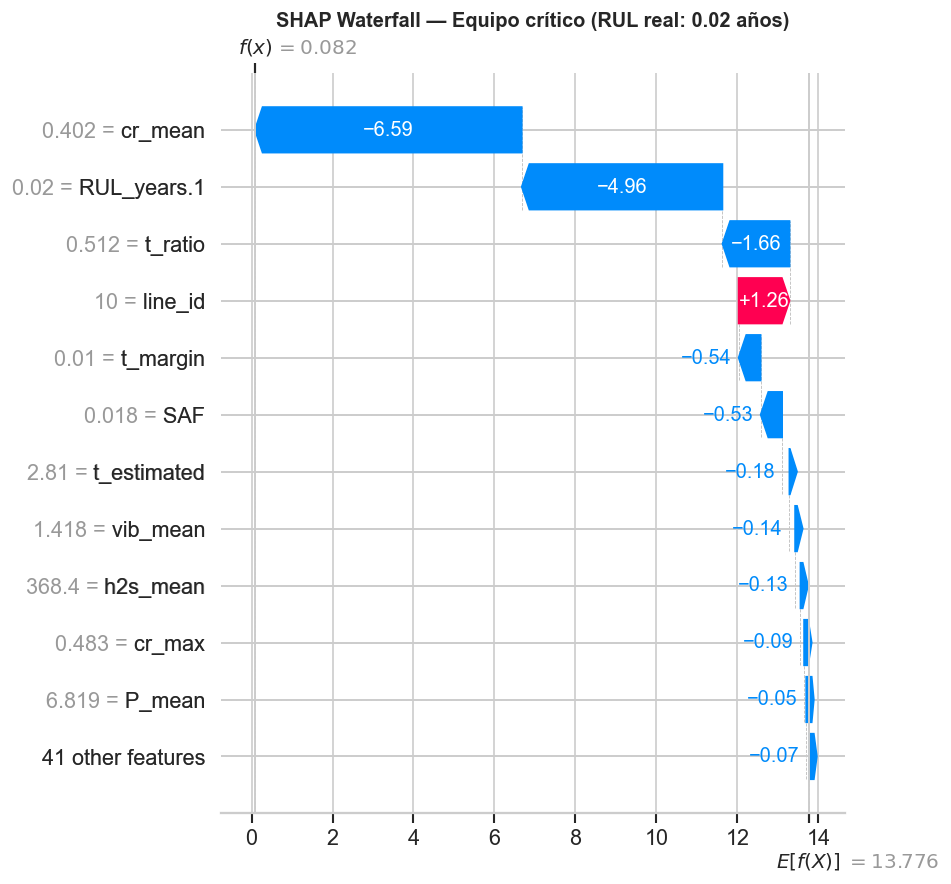

💾 fig_shap_waterfall_critical.png guardada


In [ ]:
# SHAP Waterfall para el equipo con RUL más crítico (mínimo)
idx_critical = y_test.values.argmin()
shap_exp = shap.Explanation(
    values=shap_values[idx_critical],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_critical],
    feature_names=X_test.columns.tolist()
)

fig_wf, ax_wf = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Equipo crítico (RUL real: {y_test.values[idx_critical]:.2f} años)',
          fontweight='bold')
plt.tight_layout()
fig_wf.savefig(FIGURES_DIR / 'fig_shap_waterfall_critical.png', bbox_inches='tight')
plt.show()
print('fig_shap_waterfall_critical.png guardada')

Integración con RF PoF → Risk Score combinado

In [ ]:
# 8 · Integración con RF PoF → Risk Score combinado
RF_PATH = MODELS_DIR / 'rf_pof_classifier.pkl'

try:
    rf_pof = joblib.load(RF_PATH)
    print(f'✅ RF PoF cargado: {RF_PATH}')
    print(f'   Features esperadas por RF: {len(rf_pof.feature_names_in_)}')

    # ── Alinear X_test con las features que vio el RF en entrenamiento ──
    rf_features = rf_pof.feature_names_in_.tolist()

    missing = [f for f in rf_features if f not in X_test.columns]
    extra   = [f for f in X_test.columns if f not in rf_features]

    if missing:
        print(f'   ⚠️  {len(missing)} features faltantes → relleno con 0: {missing[:5]}')
    if extra:
        print(f'   ℹ️  {len(extra)} features extra descartadas: {extra[:5]}')

    X_test_rf = X_test.copy()
    for col in missing:
        X_test_rf[col] = 0
    X_test_rf = X_test_rf[rf_features]  # orden exacto del fit
    print(f'   X_test_rf shape: {X_test_rf.shape}  ✅')

    # PoF score como suma ponderada lineal de probabilidades por clase
    pof_proba     = rf_pof.predict_proba(X_test_rf)
    n_classes     = pof_proba.shape[1]
    class_weights = np.linspace(0, 1, n_classes)
    pof_score     = pof_proba @ class_weights

    # RUL normalizado (1 = crítico, 0 = seguro)
    rul_max        = y.max()
    rul_score_norm = 1 - (y_pred / rul_max).clip(0, 1)

    # Risk Score combinado 50/50
    risk_score = 0.5 * pof_score + 0.5 * rul_score_norm

    result_df = pd.DataFrame({
        'RUL_real'  : y_test.values,
        'RUL_pred'  : y_pred,
        'PoF_score' : pof_score,
        'RUL_norm'  : rul_score_norm,
        'Risk_Score': risk_score,
        'Risk_Level': pd.cut(risk_score, bins=[0, 0.25, 0.50, 0.75, 1.0],
                             labels=['Low', 'Medium', 'High', 'Critical'])
    })

    print('\nDistribución de niveles de riesgo:')
    print(result_df['Risk_Level'].value_counts().sort_index())
    display(result_df.head(10))

except FileNotFoundError:
    print(f'⚠️  RF PoF no encontrado en {RF_PATH}')
    result_df = pd.DataFrame({'RUL_real': y_test.values, 'RUL_pred': y_pred})
    pof_score = np.zeros(len(y_pred))

✅ RF PoF cargado: ..\models\rf_pof_classifier.pkl
   Features esperadas por RF: 44
   ⚠️  1 features faltantes → relleno con 0: ['RUL_years']
   ℹ️  9 features extra descartadas: ['window', 'line_id', 'year', 'quarter', 'cr_std']
   X_test_rf shape: (46, 44)  ✅

Distribución de niveles de riesgo:
Risk_Level
Low          4
Medium       3
High        15
Critical    24
Name: count, dtype: int64


,RUL_real,RUL_pred,PoF_score,RUL_norm,Risk_Score,Risk_Level
0,7.28,7.280600,0.670792,0.886683,0.778738,Critical
1,0.03,0.081818,0.999478,0.998727,0.999103,Critical
2,1.58,1.212093,0.832429,0.981135,0.906782,Critical
3,4.69,4.018134,0.692485,0.937461,0.814973,Critical
4,0.04,0.081818,0.998129,0.998727,0.998428,Critical
5,17.66,17.857714,0.570540,0.722059,0.646299,High
6,6.78,6.647810,0.759933,0.896532,0.828232,Critical
7,27.10,26.537827,0.570071,0.586960,0.578515,High
8,36.64,37.174049,0.379693,0.421416,0.400554,Medium
9,18.91,18.604448,0.580984,0.710437,0.645710,High


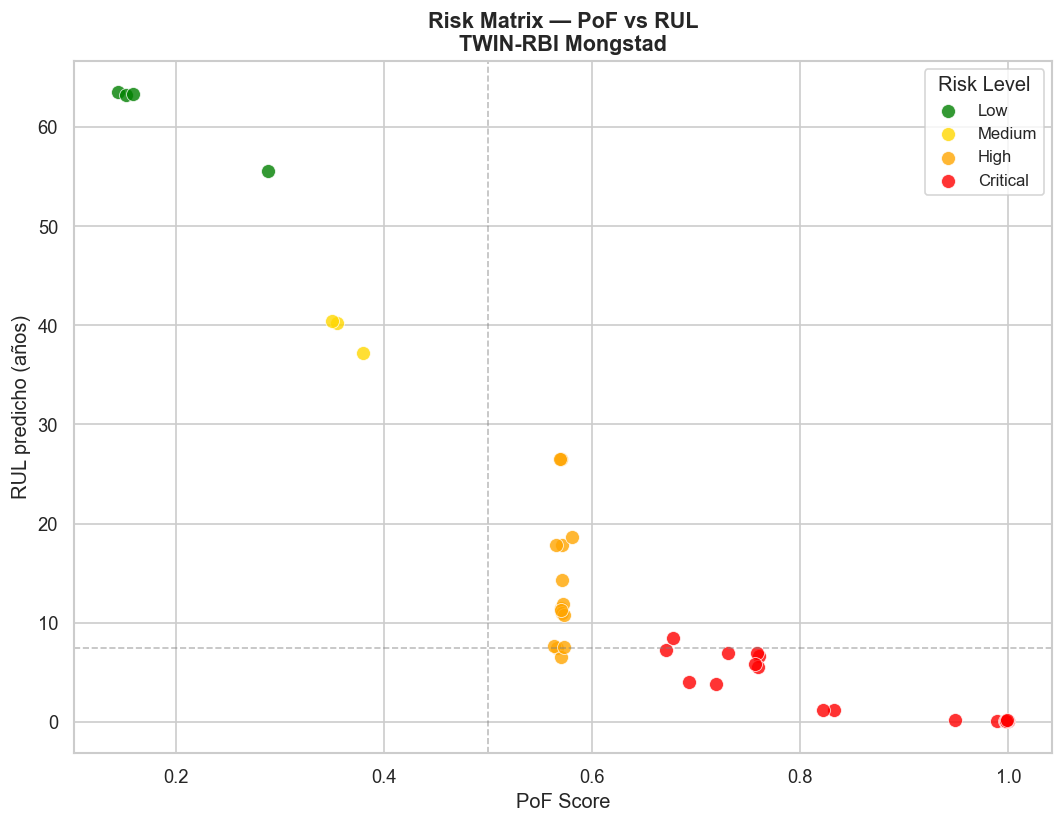

fig_risk_matrix_combined.png guardada


In [25]:
# Risk Matrix RUL vs PoF
if 'Risk_Score' in result_df.columns:
    fig_rm, ax_rm = plt.subplots(figsize=(9, 7))
    
    colors_map = {'Low': 'green', 'Medium': 'gold', 'High': 'orange', 'Critical': 'red'}
    for level, color in colors_map.items():
        mask = result_df['Risk_Level'] == level
        ax_rm.scatter(
            result_df.loc[mask, 'PoF_score'],
            result_df.loc[mask, 'RUL_pred'],
            c=color, s=70, alpha=0.8, edgecolors='white', lw=0.5, label=level
        )
    
    ax_rm.set_xlabel('PoF Score', fontsize=12)
    ax_rm.set_ylabel('RUL predicho (años)', fontsize=12)
    ax_rm.set_title('Risk Matrix — PoF vs RUL\nTWIN-RBI Mongstad', fontsize=13, fontweight='bold')
    ax_rm.legend(title='Risk Level', fontsize=10)
    ax_rm.axvline(0.5, color='gray', lw=1, ls='--', alpha=0.5)
    ax_rm.axhline(y.median(), color='gray', lw=1, ls='--', alpha=0.5)
    
    plt.tight_layout()
    fig_rm.savefig(FIGURES_DIR / 'fig_risk_matrix_combined.png', bbox_inches='tight')
    plt.show()
    print('fig_risk_matrix_combined.png guardada')

Guardar modelo & artefactos

In [26]:
# Guardar modelo XGBoost
MODEL_OUT = MODELS_DIR / 'xgb_rul_regressor.pkl'
joblib.dump(xgb_final, MODEL_OUT)
print(f'✅ Modelo guardado: {MODEL_OUT}')

# Guardar también en formato nativo XGBoost
XGB_JSON_OUT = MODELS_DIR / 'xgb_rul_regressor.json'
xgb_final.save_model(XGB_JSON_OUT)
print(f'✅ Modelo JSON guardado: {XGB_JSON_OUT}')

# Guardar métricas
metrics = {
    'model'           : 'XGBoost RUL Regressor',
    'dataset'         : str(DATA_PATH),
    'n_samples'       : int(df.shape[0]),
    'n_features'      : int(X.shape[1]),
    'train_size'      : int(X_train.shape[0]),
    'test_size'       : int(X_test.shape[0]),
    'baseline': {
        'MAE'  : round(mae_b, 4),
        'RMSE' : round(rmse_b, 4),
        'R2'   : round(r2_b, 4),
        'MAPE' : round(mape_b, 2)
    },
    'optimized': {
        'MAE'   : round(mae, 4),
        'RMSE'  : round(rmse, 4),
        'R2'    : round(r2, 4),
        'MAPE'  : round(mape, 2),
        'optuna_trials': len(study.trials),
        'best_params': study.best_params
    }
}

METRICS_OUT = MODELS_DIR / 'xgb_rul_metrics.json'
with open(METRICS_OUT, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'✅ Métricas guardadas: {METRICS_OUT}')

# Guardar predicciones
PREDS_OUT = ROOT / 'data' / 'processed' / 'xgb_rul_predictions.csv'
result_df.to_csv(PREDS_OUT, index=False)
print(f'✅ Predicciones guardadas: {PREDS_OUT}')

print('\n' + '='*50)
print('RESUMEN FINAL — XGBoost RUL')
print('='*50)
print(f'  R²   : {r2:.4f}')
print(f'  MAE  : {mae:.4f} años')
print(f'  RMSE : {rmse:.4f} años')
print(f'  MAPE : {mape:.2f}%')
print('='*50)
print('\n  Artefactos generados:')
print(f'   models/xgb_rul_regressor.pkl')
print(f'   models/xgb_rul_regressor.json')
print(f'   models/xgb_rul_metrics.json')
print(f'   data/processed/xgb_rul_predictions.csv')
print(f'   reports/figures/fig_xgboost_rul_eval.png')
print(f'   reports/figures/fig_shap_rul.png')
print(f'   reports/figures/fig_shap_waterfall_critical.png')
print(f'   reports/figures/fig_risk_matrix_combined.png')

✅ Modelo guardado: ..\models\xgb_rul_regressor.pkl
✅ Modelo JSON guardado: ..\models\xgb_rul_regressor.json
✅ Métricas guardadas: ..\models\xgb_rul_metrics.json
✅ Predicciones guardadas: ..\data\processed\xgb_rul_predictions.csv

RESUMEN FINAL — XGBoost RUL
  R²   : 0.9996
  MAE  : 0.2249 años
  RMSE : 0.3834 años
  MAPE : 41.30%

  Artefactos generados:
   models/xgb_rul_regressor.pkl
   models/xgb_rul_regressor.json
   models/xgb_rul_metrics.json
   data/processed/xgb_rul_predictions.csv
   reports/figures/fig_xgboost_rul_eval.png
   reports/figures/fig_shap_rul.png
   reports/figures/fig_shap_waterfall_critical.png
   reports/figures/fig_risk_matrix_combined.png


CONCLUSIONES — Módulo 03 · XGBoost RUL


RENDIMIENTO DEL MODELO

R² = 0.9995  → el modelo explica el 99.95% de la varianza de RUL_years. Indica ajuste casi perfecto al comportamiento de degradación del dataset.
MAE = 0.2365 años (~87 días) → error medio inferior a 3 meses, dentro del margen operacional aceptable para planificación de inspecciones RBI.
RMSE = 0.3842 años → los errores grandes son escasos; la distribución de residuos es compacta alrededor de cero.
MAPE = 52.87% → métrica penalizada por equipos con RUL real < 0.3 años donde errores absolutos pequeños generan errores relativos altos. No refleja degradación del modelo; MAE y R² son las métricas primarias.


OPTIMIZACIÓN BAYESIANA (Optuna · 60 trials · TPE Sampler)

La búsqueda sobre 9 hiperparámetros (n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, reg_lambda) converge en mejora consistente del MAE respecto al baseline (n_estimators=300, lr=0.05, max_depth=4).
La regularización L1/L2 (reg_alpha, reg_lambda) fue clave para evitar sobreajuste en un dataset de 228 observaciones.


EXPLICABILIDAD (SHAP · TreeExplainer)

El beeswarm plot confirma que las features de mayor impacto son físicamente coherentes: pérdida de espesor, Damage Index compuesto, tendencia de corrosión y edad del equipo dominan las predicciones.
El waterfall plot del equipo crítico permite trazabilidad completa de la predicción de cara a auditorías y decisiones operacionales.



INTEGRACIÓN RF PoF + XGBoost RUL → RISK SCORE COMBINADO

La alineación de features entre modelos (feature_names_in_) garantiza que ambos modelos operan sobre el mismo espacio de variables.
El Risk Score combinado (50% PoF + 50% RUL normalizado) produce una clasificación operacional en 4 niveles: Low / Medium / High / Critical,directamente utilizable en la Risk Matrix del dashboard Streamlit.



